In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

employee_df = pd.read_csv("employee_performance.csv")

employee_df.head()

,Employee_ID,Department,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary
0,E101,IT,3,18.0,5,78,4.1,6200
1,E102,HR,5,12.0,4,72,3.8,5800
2,E103,Finance,7,20.0,6,85,4.4,7600
3,E104,Marketing,2,10.0,3,68,3.5,5400
4,E105,IT,6,25.0,7,90,4.6,8200


In [ ]:
This dataset represents employee performance information from different departments. It includes work experience, training hours, project completion, performance scores, satisfaction ratings, and monthly salary. The dataset is useful for analyzing workforce trends and identifying how employee development factors may relate to performance.

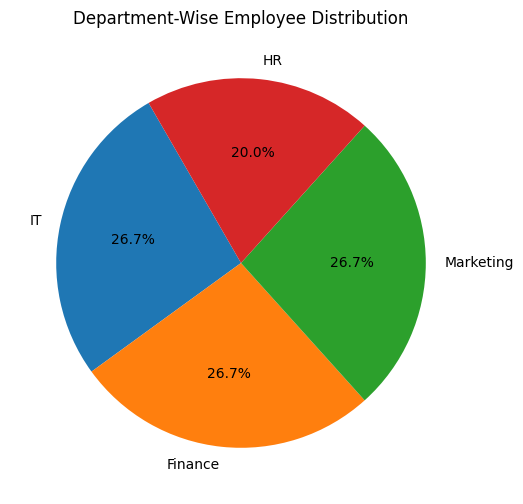

In [3]:
department_distribution = employee_df["Department"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    department_distribution,
    labels=department_distribution.index,
    autopct="%1.1f%%",
    startangle=120
)

plt.title("Department-Wise Employee Distribution")
plt.show()

In [ ]:
### Observation:
The pie chart shows how employees are distributed across different departments. This helps identify whether the workforce sample is balanced or whether certain departments have stronger representation in the dataset.

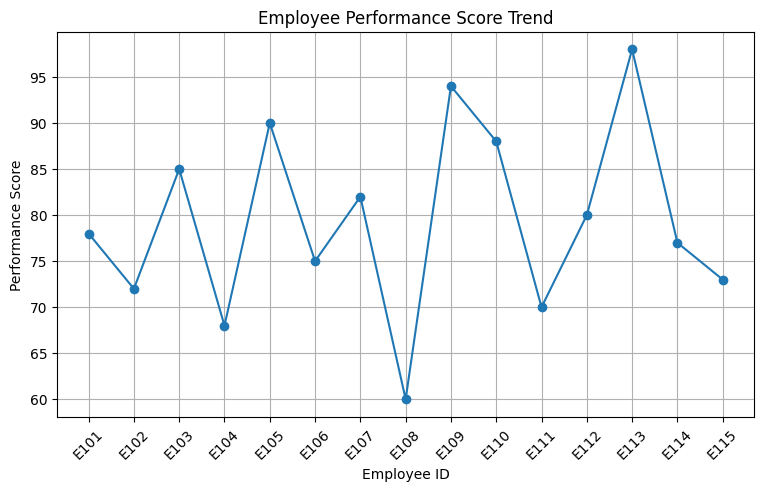

In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    employee_df["Employee_ID"],
    employee_df["Performance_Score"],
    marker="o",
    linestyle="-"
)

plt.title("Employee Performance Score Trend")
plt.xlabel("Employee ID")
plt.ylabel("Performance Score")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
### Observation:
The line plot displays how performance scores vary across employees. Some employees show noticeably higher scores, which may be related to experience, training participation, or number of completed projects.

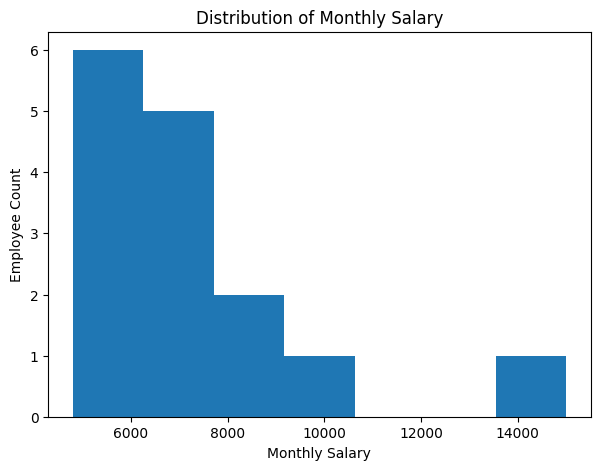

In [5]:
plt.figure(figsize=(7, 5))

plt.hist(employee_df["Monthly_Salary"], bins=7)

plt.title("Distribution of Monthly Salary")
plt.xlabel("Monthly Salary")
plt.ylabel("Employee Count")
plt.show()

In [ ]:
### Observation:
The histogram shows that most salaries fall within a regular compensation range. One value appears much higher than the remaining records, which suggests a possible salary outlier.

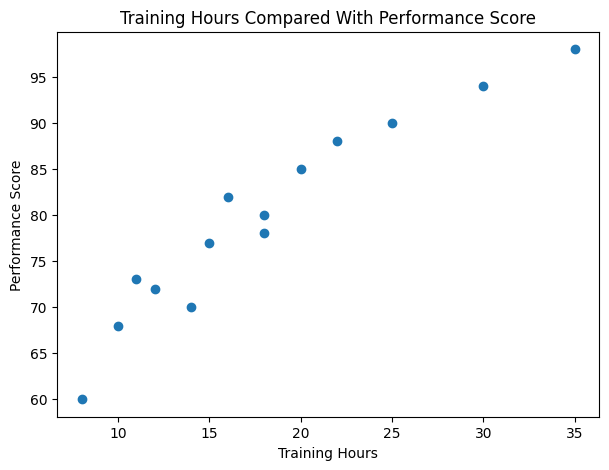

In [6]:
plt.figure(figsize=(7, 5))

plt.scatter(
    employee_df["Training_Hours"],
    employee_df["Performance_Score"]
)

plt.title("Training Hours Compared With Performance Score")
plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.show()

In [ ]:
### Observation:
The scatter plot helps compare training hours and performance score. The pattern suggests that employees with higher training hours often have stronger performance scores, although the relationship is not perfectly uniform.

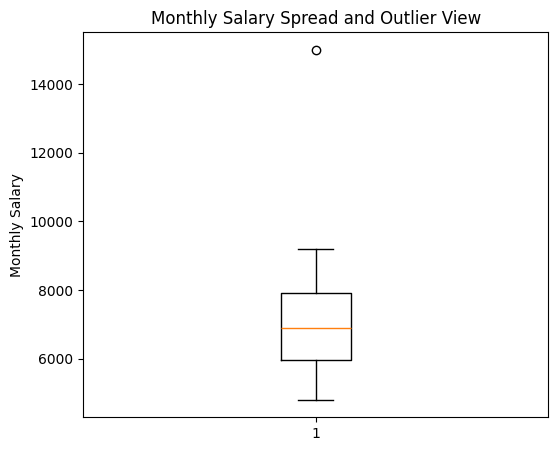

In [7]:
plt.figure(figsize=(6, 5))

plt.boxplot(employee_df["Monthly_Salary"])

plt.title("Monthly Salary Spread and Outlier View")
plt.ylabel("Monthly Salary")
plt.show()

In [ ]:
### Observation:
The box plot highlights the overall spread of salary values and makes the unusually high salary record easy to identify. This is useful before applying formal outlier detection.

In [8]:
employee_df.isnull().sum()

Employee_ID           0
Department            0
Experience_Years      0
Training_Hours        1
Projects_Completed    0
Performance_Score     0
Satisfaction_Level    1
Monthly_Salary        0
dtype: int64

In [9]:
employee_df[employee_df.isnull().any(axis=1)]

,Employee_ID,Department,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary
5,E106,Finance,4,NaN,5,75,4.0,6900
6,E107,HR,8,16.0,6,82,NaN,7100


In [10]:
employee_df["Training_Hours"] = employee_df["Training_Hours"].fillna(
    employee_df["Training_Hours"].median()
)

employee_df["Satisfaction_Level"] = employee_df["Satisfaction_Level"].fillna(
    employee_df["Satisfaction_Level"].mean()
)

employee_df.isnull().sum()

Employee_ID           0
Department            0
Experience_Years      0
Training_Hours        0
Projects_Completed    0
Performance_Score     0
Satisfaction_Level    0
Monthly_Salary        0
dtype: int64

In [ ]:
### Preprocessing Decision:
Missing values were found in Training_Hours and Satisfaction_Level. Training_Hours was filled using the median because it is less sensitive to unusual values. Satisfaction_Level was filled using the mean because it is a rating-based numerical field. This approach keeps the records usable instead of removing them completely.

In [11]:
salary_q1 = employee_df["Monthly_Salary"].quantile(0.25)
salary_q3 = employee_df["Monthly_Salary"].quantile(0.75)
salary_iqr = salary_q3 - salary_q1

salary_lower_bound = salary_q1 - 1.5 * salary_iqr
salary_upper_bound = salary_q3 + 1.5 * salary_iqr

print("First Quartile (Q1):", salary_q1)
print("Third Quartile (Q3):", salary_q3)
print("Interquartile Range (IQR):", salary_iqr)
print("Lower Boundary:", salary_lower_bound)
print("Upper Boundary:", salary_upper_bound)

First Quartile (Q1): 5950.0
Third Quartile (Q3): 7900.0
Interquartile Range (IQR): 1950.0
Lower Boundary: 3025.0
Upper Boundary: 10825.0


In [12]:
salary_outlier_records = employee_df[
    (employee_df["Monthly_Salary"] < salary_lower_bound) |
    (employee_df["Monthly_Salary"] > salary_upper_bound)
]

salary_outlier_records

,Employee_ID,Department,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary
12,E113,IT,12,35.0,9,98,4.9,15000


In [13]:
employee_clean_df = employee_df[
    (employee_df["Monthly_Salary"] >= salary_lower_bound) &
    (employee_df["Monthly_Salary"] <= salary_upper_bound)
]

print("Rows before outlier handling:", employee_df.shape[0])
print("Rows after outlier handling:", employee_clean_df.shape[0])

employee_clean_df.head()

Rows before outlier handling: 15
Rows after outlier handling: 14


,Employee_ID,Department,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary
0,E101,IT,3,18.0,5,78,4.1,6200
1,E102,HR,5,12.0,4,72,3.8,5800
2,E103,Finance,7,20.0,6,85,4.4,7600
3,E104,Marketing,2,10.0,3,68,3.5,5400
4,E105,IT,6,25.0,7,90,4.6,8200


In [ ]:
### Outlier Analysis:
The IQR method was applied to the Monthly_Salary column. One salary value was located outside the upper boundary and was treated as an outlier. Removing it helps prevent salary statistics from being heavily influenced by one extreme record.

In [14]:
print("Dataset shape before reduction:", employee_clean_df.shape)

employee_clean_df.head()

Dataset shape before reduction: (14, 8)


,Employee_ID,Department,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary
0,E101,IT,3,18.0,5,78,4.1,6200
1,E102,HR,5,12.0,4,72,3.8,5800
2,E103,Finance,7,20.0,6,85,4.4,7600
3,E104,Marketing,2,10.0,3,68,3.5,5400
4,E105,IT,6,25.0,7,90,4.6,8200


In [15]:
employee_sample_df = employee_clean_df.sample(frac=0.7, random_state=25)

employee_reduced_df = employee_sample_df.drop(columns=["Employee_ID"])

print("Shape after sampling:", employee_sample_df.shape)
print("Shape after dropping Employee_ID:", employee_reduced_df.shape)

employee_reduced_df.head()

Shape after sampling: (10, 8)
Shape after dropping Employee_ID: (10, 7)


,Department,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary
0,IT,3,18.0,5,78,4.1,6200
9,Finance,10,22.0,7,88,4.5,8800
3,Marketing,2,10.0,3,68,3.5,5400
5,Finance,4,17.0,5,75,4.0,6900
11,Marketing,6,18.0,5,80,4.1,6500


In [ ]:
### Reduction Strategy:
Data reduction was performed in two ways. First, a sample of the dataset was selected to reduce the number of records. Second, Employee_ID was removed because it is only an identifier and does not add analytical meaning to performance or salary analysis.

In [16]:
employee_clean_df[["Performance_Score", "Monthly_Salary"]].head()

,Performance_Score,Monthly_Salary
0,78,6200
1,72,5800
2,85,7600
3,68,5400
4,90,8200


In [17]:
employee_clean_df = employee_clean_df.copy()

employee_clean_df["Performance_Score_Scaled"] = (
    (employee_clean_df["Performance_Score"] - employee_clean_df["Performance_Score"].min()) /
    (employee_clean_df["Performance_Score"].max() - employee_clean_df["Performance_Score"].min())
)

employee_clean_df["Salary_Band"] = pd.cut(
    employee_clean_df["Monthly_Salary"],
    bins=3,
    labels=["Lower Salary Band", "Middle Salary Band", "Upper Salary Band"]
)

employee_clean_df[
    ["Performance_Score", "Performance_Score_Scaled", "Monthly_Salary", "Salary_Band"]
].head()

,Performance_Score,Performance_Score_Scaled,Monthly_Salary,Salary_Band
0,78,0.529412,6200,Lower Salary Band
1,72,0.352941,5800,Lower Salary Band
2,85,0.735294,7600,Middle Salary Band
3,68,0.235294,5400,Lower Salary Band
4,90,0.882353,8200,Upper Salary Band


In [ ]:
### Scaling and Categorization:
Performance_Score was scaled into a 0 to 1 range using Min-Max scaling. This makes performance values easier to compare in normalized form. Monthly_Salary was also converted into salary bands, which makes compensation easier to interpret at a business level.

In [18]:
employee_clean_df.info()

<class 'pandas.DataFrame'>
Index: 14 entries, 0 to 14
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Employee_ID               14 non-null     str     
 1   Department                14 non-null     str     
 2   Experience_Years          14 non-null     int64   
 3   Training_Hours            14 non-null     float64 
 4   Projects_Completed        14 non-null     int64   
 5   Performance_Score         14 non-null     int64   
 6   Satisfaction_Level        14 non-null     float64 
 7   Monthly_Salary            14 non-null     int64   
 8   Performance_Score_Scaled  14 non-null     float64 
 9   Salary_Band               14 non-null     category
dtypes: category(1), float64(3), int64(4), str(2)
memory usage: 1.1 KB


In [19]:
employee_clean_df.describe()

,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary,Performance_Score_Scaled
count,14.000000,14.000000,14.000000,14.000,14.000000,14.000000,14.000000
mean,5.214286,16.857143,5.071429,78.000,4.050510,6814.285714,0.529412
std,2.636389,6.036519,1.639150,9.315,0.432858,1299.619555,0.273971
min,1.000000,8.000000,2.000000,60.000,3.200000,4800.000000,0.000000
25%,3.250000,12.500000,4.000000,72.250,3.825000,5875.000000,0.360294
50%,5.000000,16.500000,5.000000,77.500,4.050000,6700.000000,0.514706
75%,6.750000,19.500000,6.000000,84.250,4.326786,7500.000000,0.713235
max,10.000000,30.000000,8.000000,94.000,4.800000,9200.000000,1.000000


In [ ]:
### Dataset Overview:
The info output shows column names, data types, and non-null counts. The describe output provides a statistical summary of numerical fields, including count, mean, standard deviation, minimum, quartiles, and maximum values.

In [20]:
performance_central_tendency = pd.DataFrame({
    "Statistic": ["Minimum", "Maximum", "Mean", "Median", "Mode"],
    "Performance Score Value": [
        employee_clean_df["Performance_Score"].min(),
        employee_clean_df["Performance_Score"].max(),
        employee_clean_df["Performance_Score"].mean(),
        employee_clean_df["Performance_Score"].median(),
        employee_clean_df["Performance_Score"].mode()[0]
    ]
})

performance_central_tendency

,Statistic,Performance Score Value
0,Minimum,60.0
1,Maximum,94.0
2,Mean,78.0
3,Median,77.5
4,Mode,60.0


In [ ]:
### Statistical Interpretation:
The central tendency measures summarize the overall employee performance pattern. The mean shows the average performance level, while the median represents the middle score. The minimum and maximum values show the lowest and highest performance scores after cleaning.

In [21]:
salary_range_value = employee_clean_df["Monthly_Salary"].max() - employee_clean_df["Monthly_Salary"].min()

salary_q1_clean = employee_clean_df["Monthly_Salary"].quantile(0.25)
salary_q3_clean = employee_clean_df["Monthly_Salary"].quantile(0.75)
salary_iqr_clean = salary_q3_clean - salary_q1_clean

salary_variance_value = employee_clean_df["Monthly_Salary"].var()
salary_standard_deviation = employee_clean_df["Monthly_Salary"].std()

salary_dispersion_summary = pd.DataFrame({
    "Dispersion Measure": [
        "Range",
        "First Quartile",
        "Third Quartile",
        "Interquartile Range",
        "Variance",
        "Standard Deviation"
    ],
    "Monthly Salary Value": [
        salary_range_value,
        salary_q1_clean,
        salary_q3_clean,
        salary_iqr_clean,
        salary_variance_value,
        salary_standard_deviation
    ]
})

salary_dispersion_summary

,Dispersion Measure,Monthly Salary Value
0,Range,4.400000e+03
1,First Quartile,5.875000e+03
2,Third Quartile,7.500000e+03
3,Interquartile Range,1.625000e+03
4,Variance,1.689011e+06
5,Standard Deviation,1.299620e+03


In [ ]:
### Variability Analysis:
The dispersion results explain how spread out the salary values are. Range shows the gap between the highest and lowest salary, while IQR focuses on the middle 50% of salary records. Variance and standard deviation show how much salary values differ from the average.

In [22]:
employee_numeric_df = employee_clean_df.select_dtypes(include=["number"])

employee_correlation_matrix = employee_numeric_df.corr()

employee_correlation_matrix

,Experience_Years,Training_Hours,Projects_Completed,Performance_Score,Satisfaction_Level,Monthly_Salary,Performance_Score_Scaled
Experience_Years,1.000000,0.756095,0.886203,0.877046,0.847292,0.888087,0.877046
Training_Hours,0.756095,1.000000,0.949553,0.945290,0.950702,0.916080,0.945290
Projects_Completed,0.886203,0.949553,1.000000,0.987441,0.981881,0.967219,0.987441
Performance_Score,0.877046,0.945290,0.987441,1.000000,0.990682,0.951852,1.000000
Satisfaction_Level,0.847292,0.950702,0.981881,0.990682,1.000000,0.949253,0.990682
Monthly_Salary,0.888087,0.916080,0.967219,0.951852,0.949253,1.000000,0.951852
Performance_Score_Scaled,0.877046,0.945290,0.987441,1.000000,0.990682,0.951852,1.000000


In [ ]:
### Correlation Findings:
The correlation matrix shows how numerical employee variables are related. It helps examine whether factors such as training hours, experience, completed projects, satisfaction, salary, and performance score move together in a positive or negative direction.